# ДЗ 4. Задание 6

In [1]:
from Bio import SeqIO
from Bio import motifs
from Bio.Seq import Seq
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

Вот это из задания 5:

In [46]:
records = SeqIO.parse("chr1.fna", "fasta")
record = next(records)
sequence_all = record.seq
sequence = sequence_all[10000:20000]

In [47]:
nucleotides = ['A', 'C', 'G', 'T']
counts = {i+j: 0 for i in nucleotides for j in nucleotides}

for i in range(len(sequence)-1):
    pair = sequence[i:i+2]
    if pair in counts:
        counts[pair] += 1
        
count_matrix = np.zeros((4, 4))

for i, n in enumerate(nucleotides):
    for j, m in enumerate(nucleotides):
        count_matrix[i, j] = counts[n + m]

In [48]:
P = count_matrix / count_matrix.sum(axis=1, keepdims=True)

df_P = pd.DataFrame(P, index=nucleotides, columns=nucleotides)
df_P

,A,C,G,T
A,0.191805,0.236936,0.418646,0.152613
C,0.270767,0.340256,0.092652,0.296326
G,0.198410,0.289861,0.339563,0.172167
T,0.104461,0.291361,0.411067,0.193111


In [58]:
for k in [1, 2, 3, 5, 7, 10, 20, 30, 40, 50, 70, 100, 250, 500, 1000]:
    Pk = np.linalg.matrix_power(P, k)
    df = pd.DataFrame(Pk, index=nucleotides, columns=nucleotides)
    print(f"\nP^{k}:")
    print(df.round(6))


P^1:
          A         C         G         T
A  0.191805  0.236936  0.418646  0.152613
C  0.270767  0.340256  0.092652  0.296326
G  0.198410  0.289861  0.339563  0.172167
T  0.104461  0.291361  0.411067  0.193111

P^2:
          A         C         G         T
A  0.199949  0.291879  0.307142  0.201030
C  0.193402  0.293122  0.298152  0.215324
G  0.201898  0.294226  0.295994  0.207882
T  0.200659  0.299305  0.289692  0.210344

P^3:
          A         C         G         T
A  0.199322  0.294289  0.297682  0.208707
C  0.198112  0.294720  0.297879  0.209289
G  0.198835  0.294315  0.297746  0.209104
T  0.198980  0.294640  0.296570  0.209810

P^5:
          A         C         G         T
A  0.198751  0.294493  0.297536  0.209220
C  0.198749  0.294499  0.297520  0.209233
G  0.198751  0.294496  0.297528  0.209225
T  0.198747  0.294499  0.297526  0.209228

P^7:
          A         C         G         T
A  0.198749  0.294497  0.297527  0.209227
C  0.198749  0.294497  0.297527  0.209227
G  0

Видно, что матрицы после 7 степени становятся одинаковыми

In [59]:
ks = list(range(1, 1001))
norms = []
P_prev = np.eye(4)

for k in ks:
    P_k = np.linalg.matrix_power(P, k)
    norm = np.linalg.norm(P_k - P_prev, 'fro')
    norms.append(norm)
    P_prev = P_k

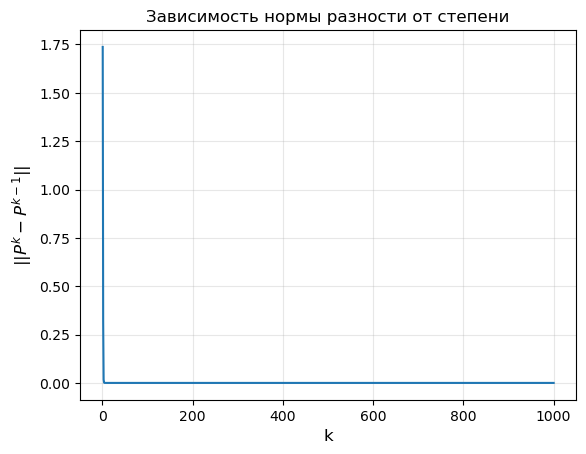

In [60]:
plt.plot(ks, norms)
plt.xlabel('k', fontsize=12)
plt.ylabel(r'$||P^k - P^{k-1}||$', fontsize=12)
plt.title('Зависимость нормы разности от степени')
plt.grid(True, alpha=0.3)

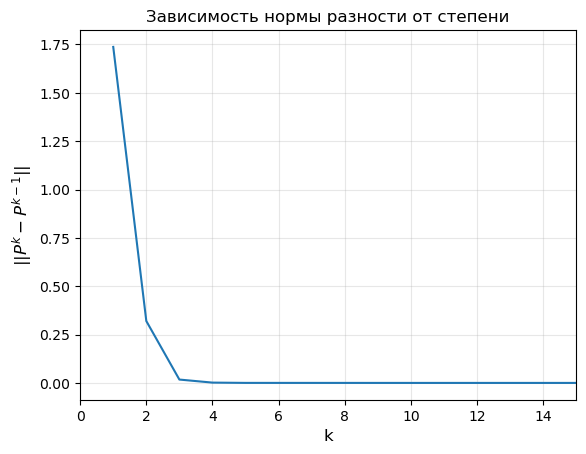

In [61]:
plt.plot(ks, norms)
plt.xlabel('k', fontsize=12)
plt.ylabel(r'$||P^k - P^{k-1}||$', fontsize=12)
plt.title('Зависимость нормы разности от степени')
plt.grid(True, alpha=0.3)
plt.xlim((0,15));

Разность норм быстро убывает к нулю, значит матрицы становятся одинаковыми

In [67]:
Pk = np.linalg.matrix_power(P, 1000)
df = pd.DataFrame(Pk, index=nucleotides, columns=nucleotides)
print(f"P^{1000}:")
df

P^1000:


,A,C,G,T
A,0.198749,0.294497,0.297527,0.209227
C,0.198749,0.294497,0.297527,0.209227
G,0.198749,0.294497,0.297527,0.209227
T,0.198749,0.294497,0.297527,0.209227


Стационарное распределение pi из прошлой задачи:
  - pi(A) = 0.198749
  - pi(C) = 0.294497
  - pi(G) = 0.297527
  - pi(T) = 0.209227

То есть при большом числе шагов марковские цепи сходтся к равномерному распределению (значения, посчитанные в 5 задании для модели равномерного распределения совпали со значениями вероятностей переходов за 1000 шагов)